# Adding a derived variable

The derived-variable registry is open: decorate a function with `@F` and its name
becomes usable everywhere a variable name is, including inside spells.

In [1]:
import os
import numpy as np
import xarray as xr
import matplotlib.pyplot as plt
import nc_time_axis  # registers the cftime axis converter for matplotlib
import x4c

x4c.set_style('journal')

# after set_style: it resets rcParams from matplotlibrc defaults, which includes the
# backend, so assert the inline backend last or figures are never captured
%matplotlib inline

# The tutorial runs against a reduced copy of a real CESM case. It is published as a
# GitHub Release asset rather than committed, so the first call downloads it into
# ~/.cache/x4c (override with $X4C_CACHE_DIR) and later calls reuse it. Set
# $X4C_SAMPLE_DIR to point at a copy you already have.
case_dir = x4c.fetch_sample_data(case='cesm1', verbose=False)
casename = os.path.basename(case_dir)
print('x4c', x4c.__version__)

x4c 2026.6.11


In [2]:
from x4c import diags
from x4c.diags import F

case = x4c.Timeseries(case_dir, grid_dict={'atm': 'ne16np4', 'ocn': 'g16'},
                      cesm_ver=1)

>>> case.root_dir: /glade/u/home/fengzhu/.cache/x4c/sample_data/cesm1_sample_data/b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.path_pattern: comp/proc/tseries/*/casename.hstr.vn.timespan.nc
>>> case.grid_dict: {'atm': 'ne16np4', 'ocn': 'g16', 'lnd': 'ne16np4', 'rof': 'ne16np4', 'ice': 'g16'}
>>> case.casename: b.e13.B1850C5.ne16_g16.icesm131_d18O_fixer.Miocene.3xCO2.005
>>> case.paths["atm"]["cam.h0"] created
>>> case.paths["ocn"]["pop.h"] created
>>> case.paths["lnd"]["clm2.h0"] created
>>> case.paths["ice"]["cice.h"] created
>>> case.vns["atm"]["cam.h0"] created
>>> case.vns["ocn"]["pop.h"] created
>>> case.vns["lnd"]["clm2.h0"] created
>>> case.vns["ice"]["cice.h"] created


## How the registry works

`@F` registers under the function name with a leading `get_` stripped, so
`get_PRECT` is registered as `PRECT`. Pass `name=` when the key is not a valid
Python identifier.

In [3]:
import inspect
print(inspect.getsource(diags.DiagCalc.get_PRECT))

    @F
    def get_PRECT(case, **kws):
        case.load('PRECC', **kws)
        case.load('PRECL', **kws)
        da = case.ds['PRECC'].x.da + case.ds['PRECL'].x.da
        # arithmetic between two DataArrays drops the DataArray-valued attrs, so the
        # grid metadata has to be put back or `.x.gm` fails
        utils.copy_grid_attrs(da, case.ds['PRECC'].x.da)
        da.name = 'PRECT'
        da.attrs['long_name'] = 'Total precipitation rate (convective + large-scale; liq + ice)'
        return da



## A new diagnostic

Anything the function needs, it loads itself through the case object. Here is the
precipitation-minus-evaporation balance, which is not a CESM output field.

In [4]:
from x4c import utils


@F
def get_PRECT_MM(case, **kws):
    """Total precipitation rate in mm/day."""
    case.load('PRECC', **kws)
    case.load('PRECL', **kws)

    precip = case.ds['PRECC'].x.da + case.ds['PRECL'].x.da   # m/s
    da = precip * 1000 * 86400                               # -> mm/day

    # Adding two DataArrays drops the DataArray-valued attrs, `gw` among them, even
    # with keep_attrs=True: a binary op keeps only attrs that are *identical* in both
    # operands, and `gw` compares as conflicting. Without this the next `.x.gm` would
    # fail with KeyError: 'gw'.
    utils.copy_grid_attrs(da, case.ds['PRECC'].x.da)

    da.name = 'PRECT_MM'
    da.attrs['long_name'] = 'Total precipitation rate'
    da.attrs['units'] = 'mm/day'
    return da


print('registered:', 'PRECT_MM' in diags.Registry.funcs)

registered: True


In [5]:
case.load('PRECT_MM', timespan=(1, 10))
da = case.ds['PRECT_MM']
print(dict(da.sizes), '|', da.attrs.get('units'))

>>> PRECT_MM is a supported derived variable.


>>> case.ds["PRECC"] created


>>> case.ds["PRECL"] created
>>> case.ds["PRECT_MM"] created
{'time': 120, 'ncol': 13826} | mm/day


Once registered, the name works in a spell like any other.

In [6]:
gm = case.calc('PRECT_MM:ann:gm', timespan=(1, 10))
print('global-mean precipitation (mm/day):')
print(np.round(gm.values, 4))

>>> PRECT_MM is a supported derived variable.
>>> case.ds["PRECC"] already loaded; to reload, run case.load("PRECC", ..., reload=True).
>>> case.ds["PRECL"] already loaded; to reload, run case.load("PRECL", ..., reload=True).


>>> case.ds["PRECT_MM"] created
>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


>>> case.diags["PRECT_MM:ann:gm"] created
global-mean precipitation (mm/day):
[3.7512 3.7133 3.7311 3.7219 3.6695 3.6605 3.6977 3.6956 3.6702 3.6508]


>>> PRECT_MM is a supported derived variable.
>>> case.ds["PRECC"] already loaded; to reload, run case.load("PRECC", ..., reload=True).
>>> case.ds["PRECL"] already loaded; to reload, run case.load("PRECL", ..., reload=True).
>>> case.ds["PRECT_MM"] created
>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


>>> case.diags["PRECT_MM|regrid(2,2):ann"] created


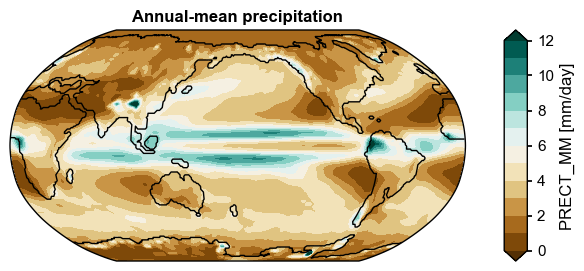

In [7]:
ssh_path = os.path.join(case_dir, 'ocn', 'proc', 'tseries', 'month_1',
                        f'{casename}.pop.h.SSH.000101-000512.nc')
ssv = x4c.open_dataset(ssh_path, comp='ocn', grid='g16', vn='SSH',
                       shift_time=True).x.regrid().x.da.mean('time')

field = case.calc('PRECT_MM|regrid(2,2):ann', timespan=(1, 10))
fig, ax = field.mean('time').x.plot(
    ssv=ssv, cmap='BrBG', levels=np.linspace(0, 12, 13),
    title='Annual-mean precipitation')
x4c.showfig(fig)

## A units caution

`calc` converts anything labelled `K` to degrees Celsius by subtracting 273.15. That
is right for an absolute temperature and wrong for a difference, an anomaly or an
index — so label those with their real units, not `K`.

In [8]:
@F
def get_TS_ANOM(case, **kws):
    """Surface-temperature anomaly about the record mean."""
    case.load('TS', **kws)
    ts = case.ds['TS'].x.da
    da = ts - ts.mean('time')
    da.name = 'TS_ANOM'
    da.attrs['long_name'] = 'Surface temperature anomaly'
    da.attrs['units'] = 'degC'    # NOT 'K': this is a difference, not a temperature
    return da


anom = case.calc('TS_ANOM:ann:gm', timespan=(1, 10))
print('anomaly (degC):', np.round(anom.values, 4))

>>> TS_ANOM is a supported derived variable.


>>> case.ds["TS"] created
>>> case.ds["TS_ANOM"] created
>>> Timespan: [0001-01-01 00:00:00, 0010-12-01 00:00:00]


>>> case.diags["TS_ANOM:ann:gm"] created
anomaly (degC): [ 0.0623  0.0213  0.175   0.1713 -0.1172 -0.0597  0.0539  0.1841 -0.1573
 -0.3337]
